In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
saldao = pd.read_csv('base/saldao.csv', sep=';', decimal=',')

In [3]:
listaemb = saldao.sort_values(by=["Cód. Barras/Etiq."], ascending=True).head(12)['Cód. Barras/Etiq.'].tolist()

In [4]:
saldao["nembalagem"] = saldao["Cód. Barras/Etiq."].apply(lambda x: x if x in listaemb else 0)

In [5]:
saldao_codigo = saldao[saldao["nembalagem"] == 0]
saldao_embalagem = saldao[saldao["nembalagem"] != 0]
saldao_codigo["Cód. Barras/Etiq."] = saldao_codigo["Cód. Barras/Etiq."].astype(str).apply(lambda x: x.zfill(13))
saldao_codigo["Cód. Barras/Etiq."] = saldao_codigo["Cód. Barras/Etiq."].astype(str)

C:\Users\leopa\AppData\Local\Temp\ipykernel_27268\383085007.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saldao_codigo["Cód. Barras/Etiq."] = saldao_codigo["Cód. Barras/Etiq."].astype(str).apply(lambda x: x.zfill(13))
C:\Users\leopa\AppData\Local\Temp\ipykernel_27268\383085007.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saldao_codigo["Cód. Barras/Etiq."] = saldao_codigo["Cód. Barras/Etiq."].astype(str)


In [6]:
listaembalagem = pd.read_csv('base/listaembalagem.csv',
                             dtype={'codigobarras': str})

In [7]:
listaembalagem["codigobarras"] = listaembalagem["codigobarras"].astype(str).apply(lambda x: x.zfill(13))
listaembalagem.loc[listaembalagem['codigobarras'] == '00079400500205', 'codigobarras'] = '0079400500205'

In [8]:
mergesaldao_cod = saldao_codigo.merge(listaembalagem, 
                left_on='Cód. Barras/Etiq.',
                right_on='codigobarras',
                how='left')


In [9]:
mergesaldao_emb = saldao_embalagem.merge(listaembalagem, 
                left_on='nembalagem',
                right_on='etiqueta',
                how='left')


In [10]:
mergesaldao = pd.concat([mergesaldao_cod, mergesaldao_emb], ignore_index=True)

In [11]:
mov = pd.read_csv('base/movestoque0906.csv')
curvaabc = pd.read_csv('base/curvaabc.csv')
produto = pd.read_csv('base/produto.csv')
embalagem = pd.read_csv('base/embalagem.csv')
classificacao = pd.read_csv('base/classificacao2.csv')

estoque = mov[['descricao_movimentacao', 'embalagemid',
       'unidadenegocioid', 'datahora','quantidade',
       'estoqueanterior', 'estoque', 'precoreferencial', 'precovenda',
       'customedio']].copy()
estoque = estoque.merge(embalagem[['id', 'produtoid', 'apresentacao', 'codigobarras', 
                         'markup', 'descricao']],
                         left_on='embalagemid', right_on='id', how='left')
estoque = estoque.merge(curvaabc[['produtoid', 'unidadenegocioid','nome']],
                            left_on=['produtoid', 'unidadenegocioid'], 
                            right_on=['produtoid', 'unidadenegocioid'], 
                            how='left')
estoque.rename(columns={'nome': 'curvaabc',
                        }, inplace=True)
estoque = estoque.merge(classificacao,
                        on='produtoid',
                        how='left'
                        )
estoque.rename(columns={'nome': 'classificacao_nome'}, inplace=True)

mapping = {
    93733: "DROGARIA JB - F01 - MATRIZ",
    93729: "DROGARIA JB - F02 - CAMERINO",
    93730: "DROGARIA JB - F03 - AILKA"
}

estoque["filial_nome"] = estoque["unidadenegocioid"].map(mapping)

mapping2 = {
    93733: 1,
    93729: 2,
    93730: 3
} 
estoque["filial_codigo"] = estoque["unidadenegocioid"].map(mapping2)
estoque = estoque[estoque['unidadenegocioid'].isin(mapping.keys())]

In [22]:
estoque.columns

Index(['descricao_movimentacao', 'embalagemid', 'unidadenegocioid', 'datahora',
       'quantidade', 'estoqueanterior', 'estoque', 'precoreferencial',
       'precovenda', 'customedio', 'id', 'produtoid', 'apresentacao',
       'codigobarras', 'markup', 'descricao', 'curvaabc', 'classificacaoid',
       'classificacao_nome', 'caminho', 'filial_nome', 'filial_codigo'],
      dtype='object')

In [26]:
estoque[estoque['codigobarras']==7899941203273][['datahora',
       'quantidade', 'precoreferencial',
       'precovenda', 'customedio',]].sort_values(by='datahora', ascending=False)

,datahora,quantidade,precoreferencial,precovenda,customedio
277826,2025-05-30 11:38:57,-1.0,82.98,141.07,85.9600
277827,2025-05-30 11:38:57,-1.0,82.98,141.07,85.9600
267564,2025-05-28 13:48:29,-1.0,82.98,141.07,85.9600
267565,2025-05-28 13:48:29,-1.0,82.98,141.07,85.9600
267582,2025-05-28 13:48:29,-1.0,82.98,141.07,85.9600
267583,2025-05-28 13:48:29,-1.0,82.98,141.07,85.9600
220029,2025-05-10 12:16:29,-1.0,82.98,141.07,82.9834
220030,2025-05-10 12:16:29,-1.0,82.98,141.07,82.9834
126151,2025-04-10 13:22:11,2.0,82.98,141.07,85.9600
126152,2025-04-10 13:22:11,2.0,82.98,141.07,85.9600


In [12]:
df_saldao = mergesaldao[mergesaldao['Un. Neg.'].isin([1,2,3])][['Un. Neg.','produtoid']].drop_duplicates()
df_saldao.rename(columns={'Un. Neg.': 'filial_codigo'}, inplace=True)
estoque_filtro = estoque[~estoque['produtoid'].isna()]
estoque_filtro['produtoid'] = estoque_filtro['produtoid'].astype(int)

C:\Users\leopa\AppData\Local\Temp\ipykernel_27268\149480312.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_filtro['produtoid'] = estoque_filtro['produtoid'].astype(int)


In [13]:
df_saldao.to_csv('base/saldao_upload.csv', index=False)

In [14]:
# Criar uma coluna auxiliar em ambos os DataFrames
df_saldao['chave'] = df_saldao['filial_codigo'].astype(str) + '_' + df_saldao['produtoid'].astype(str)
estoque_filtro['chave'] = estoque_filtro['filial_codigo'].astype(str) + '_' + estoque_filtro['produtoid'].astype(str)

# Filtrar estoque
estoque_filtrado = estoque_filtro[estoque_filtro['chave'].isin(df_saldao['chave'].tolist())]

C:\Users\leopa\AppData\Local\Temp\ipykernel_27268\3519220814.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estoque_filtro['chave'] = estoque_filtro['filial_codigo'].astype(str) + '_' + estoque_filtro['produtoid'].astype(str)


In [15]:
filtro_estoque = estoque.merge(
    df_saldao,
    left_on=["filial_codigo", "produtoid"],
    right_on=["filial_codigo", "produtoid"],
    how="inner"
)


In [218]:
filtro_estoque['data'] = pd.to_datetime(filtro_estoque['datahora']).dt.date

In [223]:
filtro_estoque[filtro_estoque['descricao_movimentacao']=='Venda'].groupby(['filial_codigo','data']).agg({'quantidade':'sum'}).reset_index()

,filial_codigo,data,quantidade
0,1,2025-03-01,-11.0
1,1,2025-03-02,-3.0
2,1,2025-03-03,-14.0
3,1,2025-03-04,-6.0
4,1,2025-03-05,-5.0
...,...,...,...
116,3,2025-06-05,-2.0
117,3,2025-06-06,-2.0
118,3,2025-06-07,-3.0
119,3,2025-06-08,-5.0


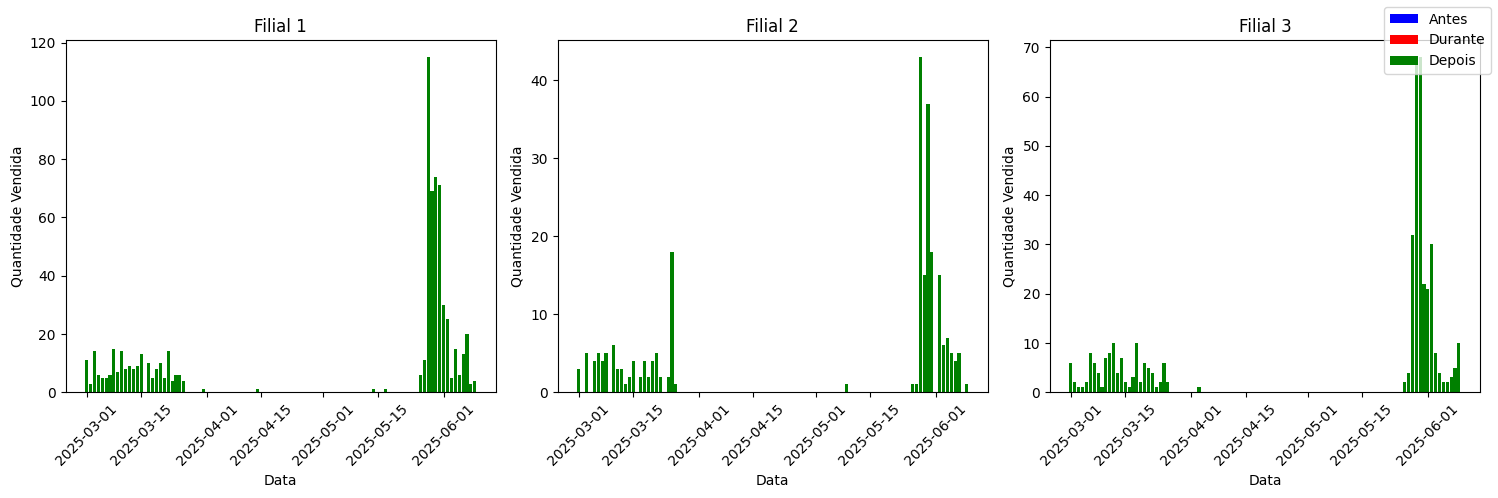

Análise de Impacto da Promoção:

Filial 1:
  Depois: 15.4 unidades/dia

Filial 2:
  Depois: 7.0 unidades/dia

Filial 3:
  Depois: 9.4 unidades/dia


In [224]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Converter quantidade para positiva (assumindo que vendas são negativas)
filtro_estoque['quantidade'] = filtro_estoque['quantidade'].abs()

# Converter coluna data para datetime se necessário
filtro_estoque['data'] = pd.to_datetime(filtro_estoque['data'])

# Agrupar por filial, data e somar quantidades
vendas_diarias = (filtro_estoque[filtro_estoque['descricao_movimentacao']=='Venda']
                  .groupby(['filial_codigo','data'])
                  .agg({'quantidade':'sum'})
                  .reset_index())

# Definir períodos da promoção
periodo_promocao_inicio = pd.to_datetime('2024-05-28')  # Ajuste o ano conforme necessário
periodo_promocao_fim = pd.to_datetime('2024-06-02')

# Criar coluna para identificar os períodos
def classificar_periodo(data):
    if data < periodo_promocao_inicio:
        return 'Antes'
    elif data <= periodo_promocao_fim:
        return 'Durante'
    else:
        return 'Depois'

vendas_diarias['periodo'] = vendas_diarias['data'].apply(classificar_periodo)

# Plotar gráficos para cada filial
filiais = vendas_diarias['filial_codigo'].unique()
fig, axes = plt.subplots(1, len(filiais), figsize=(15, 5))

if len(filiais) == 1:
    axes = [axes]

cores_periodo = {'Antes': 'blue', 'Durante': 'red', 'Depois': 'green'}

for i, filial in enumerate(filiais):
    dados_filial = vendas_diarias[vendas_diarias['filial_codigo'] == filial].sort_values('data')
    
    # Criar gráfico de barras colorido por período
    bars = axes[i].bar(dados_filial['data'], dados_filial['quantidade'], 
                       color=[cores_periodo[periodo] for periodo in dados_filial['periodo']])
    
    axes[i].set_title(f'Filial {filial}')
    axes[i].set_xlabel('Data')
    axes[i].set_ylabel('Quantidade Vendida')
    axes[i].tick_params(axis='x', rotation=45)

# Adicionar legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cores_periodo[periodo], label=periodo) 
                   for periodo in ['Antes', 'Durante', 'Depois']]
fig.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Calcular médias por período
print("Análise de Impacto da Promoção:")
print("="*50)

for filial in filiais:
    dados_filial = vendas_diarias[vendas_diarias['filial_codigo'] == filial]
    medias = dados_filial.groupby('periodo')['quantidade'].mean()
    
    print(f"\nFilial {filial}:")
    for periodo in ['Antes', 'Durante', 'Depois']:
        if periodo in medias.index:
            print(f"  {periodo}: {medias[periodo]:.1f} unidades/dia")
    
    # Calcular variação percentual
    if 'Antes' in medias.index and 'Durante' in medias.index:
        variacao = ((medias['Durante'] - medias['Antes']) / medias['Antes']) * 100
        print(f"  Variação Durante vs Antes: {variacao:+.1f}%")
    
    if 'Durante' in medias.index and 'Depois' in medias.index:
        variacao_pos = ((medias['Depois'] - medias['Durante']) / medias['Durante']) * 100
        print(f"  Variação Depois vs Durante: {variacao_pos:+.1f}%")

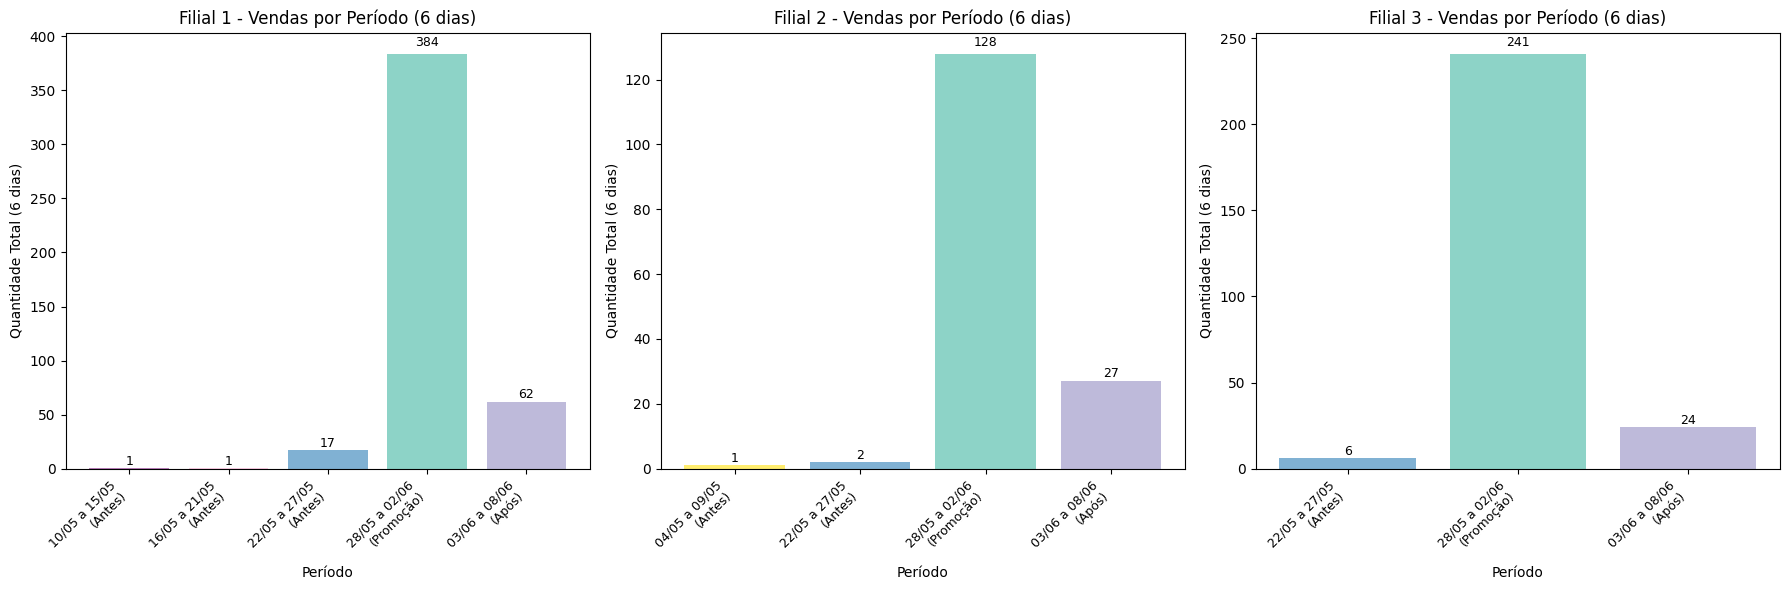

Análise de Impacto da Promoção (Períodos de 6 dias):


In [236]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

# Converter quantidade para positiva e data para datetime
filtro_estoque['quantidade'] = filtro_estoque['quantidade'].abs()
filtro_estoque['data'] = pd.to_datetime(filtro_estoque['data'])

# Filtrar período de análise (01/04 a 08/06)
data_inicio_analise = pd.to_datetime('2025-04-01')
data_fim_analise = pd.to_datetime('2025-06-08')

dados_analise = filtro_estoque[
    (filtro_estoque['data'] >= data_inicio_analise) & 
    (filtro_estoque['data'] <= data_fim_analise) &
    (filtro_estoque['descricao_movimentacao'] == 'Venda')
].copy()

# Agrupar por filial e data
vendas_diarias = (dados_analise.groupby(['filial_codigo','data'])
                  .agg({'quantidade':'sum'})
                  .reset_index())

# Definir períodos de 6 dias
promocao_inicio = pd.to_datetime('2025-05-28')
promocao_fim = pd.to_datetime('2025-06-02')

def criar_periodos_6_dias(data_ref, num_periodos_antes=4):
    periodos = {}
    
    # Usar as datas fixas da promoção
    promocao_inicio_fixo = pd.to_datetime('2025-05-28')
    promocao_fim_fixo = pd.to_datetime('2025-06-02')
    
    # Período da promoção
    periodos['Promoção (28/05-02/06)'] = {
        'inicio': promocao_inicio_fixo,
        'fim': promocao_fim_fixo
    }
    
    # Período após promoção
    periodos['Após (03/06-08/06)'] = {
        'inicio': promocao_fim_fixo + timedelta(days=1),
        'fim': promocao_fim_fixo + timedelta(days=6)
    }
    
    # Períodos antes da promoção (voltando de 6 em 6 dias)
    data_ref_atual = promocao_inicio_fixo  # Usar cópia para iteração
    
    for i in range(1, num_periodos_antes + 1):
        fim_periodo = data_ref_atual - timedelta(days=1)
        inicio_periodo = fim_periodo - timedelta(days=5)
        
        if i == 1:
            nome = f'Antes (22/05-27/05)'
        else:
            nome = f'Antes-{i} ({inicio_periodo.strftime("%d/%m")}-{fim_periodo.strftime("%d/%m")})'
        
        periodos[nome] = {
            'inicio': inicio_periodo,
            'fim': fim_periodo
        }
        
        data_ref_atual = inicio_periodo  # Atualizar a cópia
    
    return periodos

periodos = criar_periodos_6_dias(promocao_inicio)

def classificar_periodo_6_dias(data):
    for nome, periodo in periodos.items():
        if periodo['inicio'] <= data <= periodo['fim']:
            return nome
    return 'Outros'

vendas_diarias['periodo'] = vendas_diarias['data'].apply(classificar_periodo_6_dias)

# Calcular totais por período
vendas_por_periodo = (vendas_diarias.groupby(['filial_codigo', 'periodo'])
                      .agg({'quantidade': 'sum'})
                      .reset_index())

# Plotar gráficos
filiais = sorted(vendas_diarias['filial_codigo'].unique())
fig, axes = plt.subplots(1, len(filiais), figsize=(18, 6))

if len(filiais) == 1:
    axes = [axes]

# Cores para diferentes períodos
cores = plt.cm.Set3(np.linspace(0, 1, len(periodos)))
cores_periodo = {list(periodos.keys())[i]: cores[i] for i in range(len(periodos))}

for i, filial in enumerate(filiais):
    dados_filial = vendas_por_periodo[vendas_por_periodo['filial_codigo'] == filial]
    
    # Ordenar períodos cronologicamente pelo início
    periodos_ordenados = sorted(
        [p for p in dados_filial['periodo'].unique() if p in periodos],
        key=lambda x: periodos[x]['inicio']
    )
    dados_filial_ordenado = dados_filial.set_index('periodo').reindex(periodos_ordenados).reset_index()
    dados_filial_ordenado = dados_filial_ordenado.dropna()
    
    # Criar labels limpos com datas
    labels_limpos = []
    for nome in periodos_ordenados:
        inicio = periodos[nome]['inicio']
        fim = periodos[nome]['fim']
        periodo_str = f"{inicio.strftime('%d/%m')} a {fim.strftime('%d/%m')}"
        if 'Promoção' in nome:
            labels_limpos.append(f'{periodo_str}\n(Promoção)')
        elif 'Após' in nome:
            labels_limpos.append(f'{periodo_str}\n(Após)')
        else:
            labels_limpos.append(f'{periodo_str}\n(Antes)')
    
    bars = axes[i].bar(range(len(dados_filial_ordenado)), 
                       dados_filial_ordenado['quantidade'],
                       color=[cores_periodo.get(p, 'gray') for p in periodos_ordenados])
    
    axes[i].set_title(f'Filial {filial} - Vendas por Período (6 dias)')
    axes[i].set_xlabel('Período')
    axes[i].set_ylabel('Quantidade Total (6 dias)')
    axes[i].set_xticks(range(len(labels_limpos)))
    axes[i].set_xticklabels(labels_limpos, rotation=45, ha='right', fontsize=9)
    
    # Adicionar valores nas barras
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                     f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Análise específica: 6 dias antes, durante e depois
print("Análise de Impacto da Promoção (Períodos de 6 dias):")
print("="*60)




In [192]:
loja1 = df_saldao[df_saldao['filial_codigo']==1]['produtoid'].tolist()

In [209]:
mergesaldao

,Un. Neg.,Cód. Barras/Etiq.,Embalagem,P. Oferta,N_Preço Ajustado,nembalagem,produtoid,codigobarras,descricao,apresentacao,etiqueta,precoreferencial,markup,precovenda
0,1,7898953484854,CORTADOR DE COMPRIMIDOS CRISTAL,5.98,4.99,0,700582,7898953484854,CORTADOR DE COMPRIMIDOS CRISTAL,NaN,37937,4.27,40.0468,5.98
1,1,7899941203273,100% PURE WHEY 900G BAUNILHA,141.07,84.99,0,376661,7899941203273,100% PURE WHEY 900G BAUNILHA,NaN,31525,82.98,70.0048,141.07
2,1,7891158106538,PEDIASURE 400G BAUNILHA,72.58,50.99,0,296242,7891158106538,PEDIASURE 400G BAUNILHA,NaN,29901,61.50,18.0163,72.58
3,1,7899941203280,100% PURE WHEY 900G CHOCOLATE,152.94,91.99,0,331116,7899941203280,100% PURE WHEY 900G CHOCOLATE,NaN,30605,89.96,70.0089,152.94
4,1,7891158106545,PEDIASURE 400G MORANGO,68.42,47.99,0,8254187,7891158106545,PEDIASURE 400G MORANGO,NaN,48520,57.98,18.0062,68.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6490,4,36872,LIXA DE UNHA MERHEJE GOLD POTE,0.60,0.99,36872,645817,0000000000nan,LIXA DE UNHA MERHEJE GOLD POTE,NaN,36872,0.43,39.5349,0.60
6491,9,39193,TOP WHEY BAR 41G BRIGADEIRO,6.56,3.99,39193,765178,0000000000nan,TOP WHEY BAR 41G BRIGADEIRO,NaN,39193,3.86,69.9482,6.56
6492,11,48556,ESPONJA DE BANHO PONJITA AMARELO,6.79,4.99,48556,8413832,0000000000nan,ESPONJA DE BANHO PONJITA AMARELO,NaN,48556,4.85,40.0000,6.79
6493,11,48558,ESPONJA DE BANHO PONJITA AZUL,6.79,4.99,48558,8413837,0000000000nan,ESPONJA DE BANHO PONJITA AZUL,NaN,48558,4.85,40.0000,6.79


In [194]:
movloja1 = mov[mov['unidadenegocioid'] == 93733].copy()

In [208]:
mergesaldao2 = mergesaldao.merge(embalagem[['produtoid','id','codigobarras','etiqueta']],
                  on = 'etiqueta',
                  how = 'left')


In [206]:
mov.columns

Index(['codigo_movimentacao', 'descricao_movimentacao', 'embalagemid',
       'unidadenegocioid', 'datahora', 'usuarioid', 'quantidade',
       'estoqueanterior', 'estoque', 'precoreferencial', 'precovenda', 'custo',
       'customedio', 'naoatualizarestoque', 'ultimaalteracaoprecoid',
       'conversaoembalagemid', 'datahorarecalculo', 'customedioanterior',
       'estoqueanteriorproduto', 'custoponderavel', 'origemcustoponderavel'],
      dtype='object')